# Autoencoder — Abnormal Demand & Waste Detection
### Makerere University Cafeteria Dataset

**Goal:** Train an autoencoder on normal operating days (low waste, healthy sales).  
Days where the model reconstructs poorly are flagged as anomalies.

- **Normal** → low waste portions + high portions sold  
- **Abnormal** → high waste portions + low portions sold (demand spike or over-preparation)

## Step 1 — Imports

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.78.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using 

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\arian\\anaconda3\\Lib\\site-packages\\tensorflow\\python\\_pywrap_tensorflow_common.dll'
Consider using the `--user` option or check the permissions.



  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/350.9 MB 2.4 MB/s eta 0:02:26
   ---------------------------------------- 1.8/350.9 MB 2.6 MB/s eta 0:02:16
   ---------------------------------------- 2.6/350.9 MB 2.9 MB/s eta 0:02:00
   ---------------------------------------- 3.7/350.9 MB 3.3 MB/s eta 0:01:47
    --------------------------------------- 4.7/350.9 MB 3.5 MB/s eta 0:01:40
    --------------------------------------- 5.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

TensorFlow version: 2.21.0


## Step 2 — Load the Data

In [8]:
df = pd.read_csv('makerere_Cafeteria_synthetic.csv')

money_cols = ['Price_UGX', 'Revenue_UGX', 'Ingredient_Cost_UGX', 'Waste_Cost_UGX', 'Gross_Profit_UGX']
for col in money_cols:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
df.head()

(58800, 30)


,Cafeteria_ID,Cafeteria_Name,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Posho & Beans,333,306,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Matooke & Groundnut Stew,240,216,24,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Rice & Chicken,228,202,26,...,0.0,45.3,40.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Katogo (Offal+Matoke),176,128,48,...,0.0,0.0,0.0,27.1,8.7,0.0,0.0,0.0,0.0,0.0
4,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Chips & Eggs,218,195,23,...,0.0,0.0,0.0,0.0,0.0,63.3,338.5,0.0,0.0,0.0


## Step 3 — Feature Engineering

In [10]:
# sell-through: how much of what was prepared actually sold
df['Sell_Through'] = df['Portions_Sold'] / df['Portions_Prepared']

# waste ratio: waste cost as share of revenue
df['Waste_Ratio'] = df['Waste_Cost_UGX'] / df['Revenue_UGX']

# profit margin
df['Profit_Margin'] = df['Gross_Profit_UGX'] / df['Revenue_UGX']

features = ['Portions_Sold', 'Waste_Portions', 'Waste_Pct', 'Sell_Through', 'Waste_Ratio', 'Profit_Margin']

df = df.dropna(subset=features).reset_index(drop=True)
print('Records:', len(df))

Records: 58800


## Step 4 — Label Normal vs Abnormal

We define labels **per cafeteria and meal** so the threshold is relative to each location's own baseline — not a global cutoff.

Label
ABNORMAL    43710
NORMAL      15090
Name: count, dtype: int64


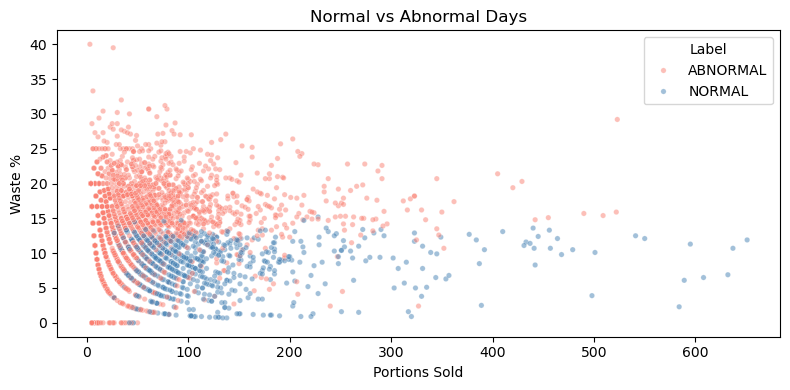

In [11]:
# compute per cafeteria+meal averages
baseline = df.groupby(['Cafeteria_ID', 'Meal']).agg(
    avg_sold      = ('Portions_Sold',  'mean'),
    avg_waste_pct = ('Waste_Pct',      'mean')
).reset_index()

df = df.merge(baseline, on=['Cafeteria_ID', 'Meal'], how='left')

# Normal   = sold >= location average AND waste_pct <= location average
# Abnormal = sold <  location average AND waste_pct >  location average
df['Label'] = 'ABNORMAL'
df.loc[
    (df['Portions_Sold'] >= df['avg_sold']) &
    (df['Waste_Pct']     <= df['avg_waste_pct']),
    'Label'
] = 'NORMAL'

print(df['Label'].value_counts())

# visualise
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df.sample(3000, random_state=42),
                x='Portions_Sold', y='Waste_Pct',
                hue='Label', palette={'NORMAL':'steelblue','ABNORMAL':'salmon'},
                alpha=0.5, s=15)
plt.title('Normal vs Abnormal Days')
plt.xlabel('Portions Sold')
plt.ylabel('Waste %')
plt.tight_layout()
plt.show()

## Step 5 — Prepare Training Data

The autoencoder is trained **only on normal records**.  
It learns what a normal day looks like. Anything it reconstructs poorly is flagged as an anomaly.

In [12]:
normal_df   = df[df['Label'] == 'NORMAL']
abnormal_df = df[df['Label'] == 'ABNORMAL']

print('Normal records  :', len(normal_df))
print('Abnormal records:', len(abnormal_df))

X_normal = normal_df[features].values
X_all    = df[features].values

# scale
scaler   = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_all_scaled    = scaler.transform(X_all)

# train/val split on normal data only
X_train, X_val = train_test_split(X_normal_scaled, test_size=0.2, random_state=42)

print('Train shape:', X_train.shape)
print('Val shape  :', X_val.shape)

Normal records  : 15090
Abnormal records: 43710
Train shape: (12072, 6)
Val shape  : (3018, 6)


## Step 6 — Build the Autoencoder

In [13]:
input_dim = X_train.shape[1]  # 6 features

# --- encoder ---
inputs  = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(inputs)
encoded = Dense(8,  activation='relu')(encoded)    # bottleneck

# --- decoder ---
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 494 (1.93 KB)

 Trainable params: 494 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Train the Autoencoder

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7351e-04 - val_loss: 6.4457e-04
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3597e-04 - val_loss: 6.4074e-04
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1103e-04 - val_loss: 6.0292e-04
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8243e-04 - val_loss: 5.6024e-04
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.6038e-04 - val_loss: 5.6393e-04
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.3708e-04 - val_loss: 5.2745e-04
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.1394e-04 - val_loss: 4.9280e-04
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9491e-04 - val_loss: 4.8253e-04
Epoch 9/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6138e-04 - val_loss: 4.4821e-04
Epoch 10/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.3605e-04 - val_loss: 4.0837e-04
Final training loss  : 0.0004
Final validation loss: 0.0004

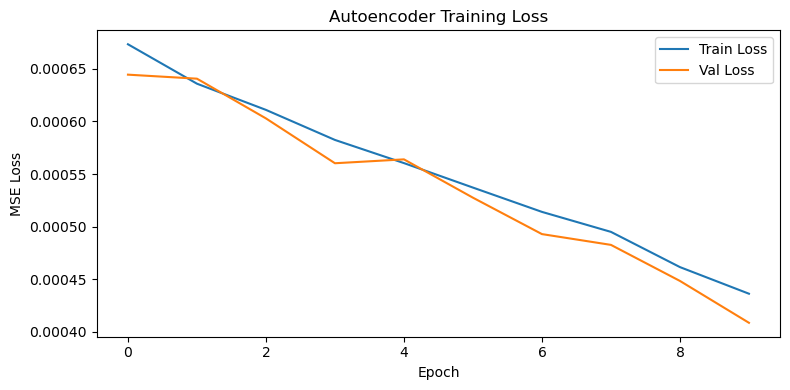

In [27]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    epochs          = 10,
    batch_size      = 64,
    validation_data = (X_val, X_val),
    callbacks       = [early_stop],
    verbose         = 1
)
print('Final training loss  :', round(history.history['loss'][-1], 4))
print('Final validation loss:', round(history.history['val_loss'][-1], 4))
# plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Set Anomaly Threshold

378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Anomaly threshold (reconstruction error): 0.0021


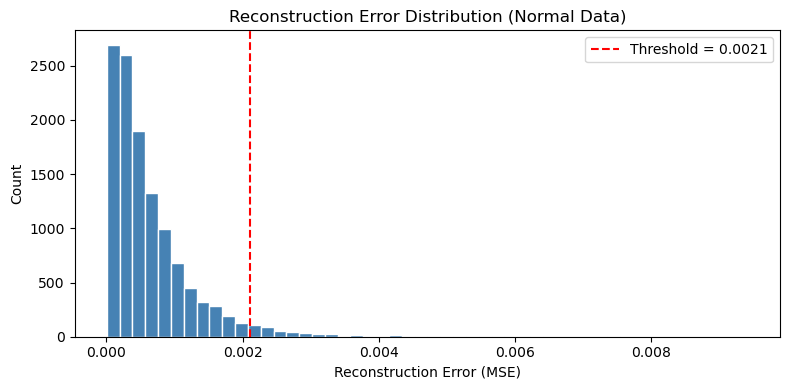

In [16]:
# reconstruction error on normal training data
X_train_pred = autoencoder.predict(X_train)
train_errors = np.mean(np.power(X_train - X_train_pred, 2), axis=1)

# threshold = mean + 2 standard deviations of normal errors
threshold = np.mean(train_errors) + 2 * np.std(train_errors)
print('Anomaly threshold (reconstruction error):', round(threshold, 4))

# plot error distribution on normal data
plt.figure(figsize=(8, 4))
plt.hist(train_errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.title('Reconstruction Error Distribution (Normal Data)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Detect Anomalies on Full Dataset

In [17]:
# reconstruct all records
X_all_pred = autoencoder.predict(X_all_scaled)
all_errors = np.mean(np.power(X_all_scaled - X_all_pred, 2), axis=1)

df['Reconstruction_Error'] = all_errors
df['Anomaly'] = df['Reconstruction_Error'] > threshold

print('Total anomalies detected:', df['Anomaly'].sum())
print('Normal days flagged correctly:', df[df['Label']=='NORMAL']['Anomaly'].sum(), 'missed')
print('Abnormal days caught:', df[df['Label']=='ABNORMAL']['Anomaly'].sum(), 'out of', len(abnormal_df))

1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Total anomalies detected: 29322
Normal days flagged correctly: 603 missed
Abnormal days caught: 28719 out of 43710


## Step 10 — Evaluate

=== Classification Report ===
              precision    recall  f1-score   support

      NORMAL       0.49      0.96      0.65     15090
    ABNORMAL       0.98      0.66      0.79     43710

    accuracy                           0.73     58800
   macro avg       0.74      0.81      0.72     58800
weighted avg       0.85      0.73      0.75     58800



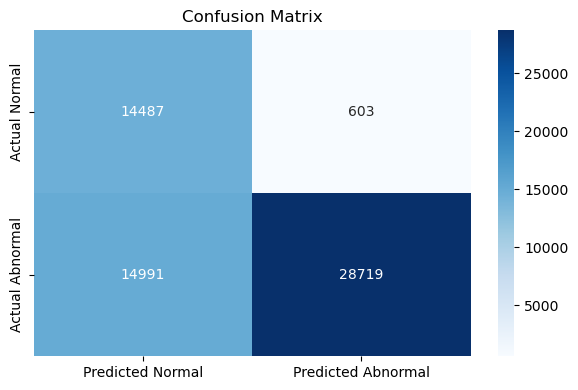

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

# convert labels to binary: ABNORMAL=1, NORMAL=0
y_true = (df['Label']  == 'ABNORMAL').astype(int)
y_pred = (df['Anomaly'] == True).astype(int)

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'ABNORMAL']))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Abnormal'],
            yticklabels=['Actual Normal',    'Actual Abnormal'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

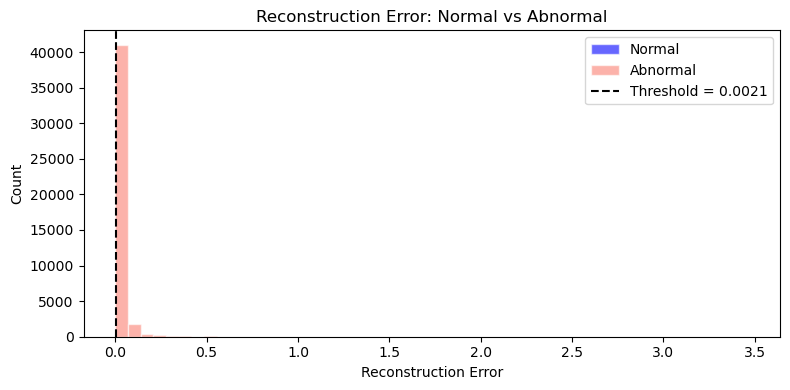

In [ ]:
# reconstruction error: normal vs abnormal days
plt.figure(figsize=(8, 4))
plt.hist(df[df['Label']=='NORMAL']['Reconstruction_Error'],
         bins=50, alpha=0.6, color='steelblue', label='Normal', edgecolor='white')
plt.hist(df[df['Label']=='ABNORMAL']['Reconstruction_Error'],
         bins=50, alpha=0.6, color='salmon',    label='Abnormal', edgecolor='white')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.title('Reconstruction Error: Normal vs Abnormal')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

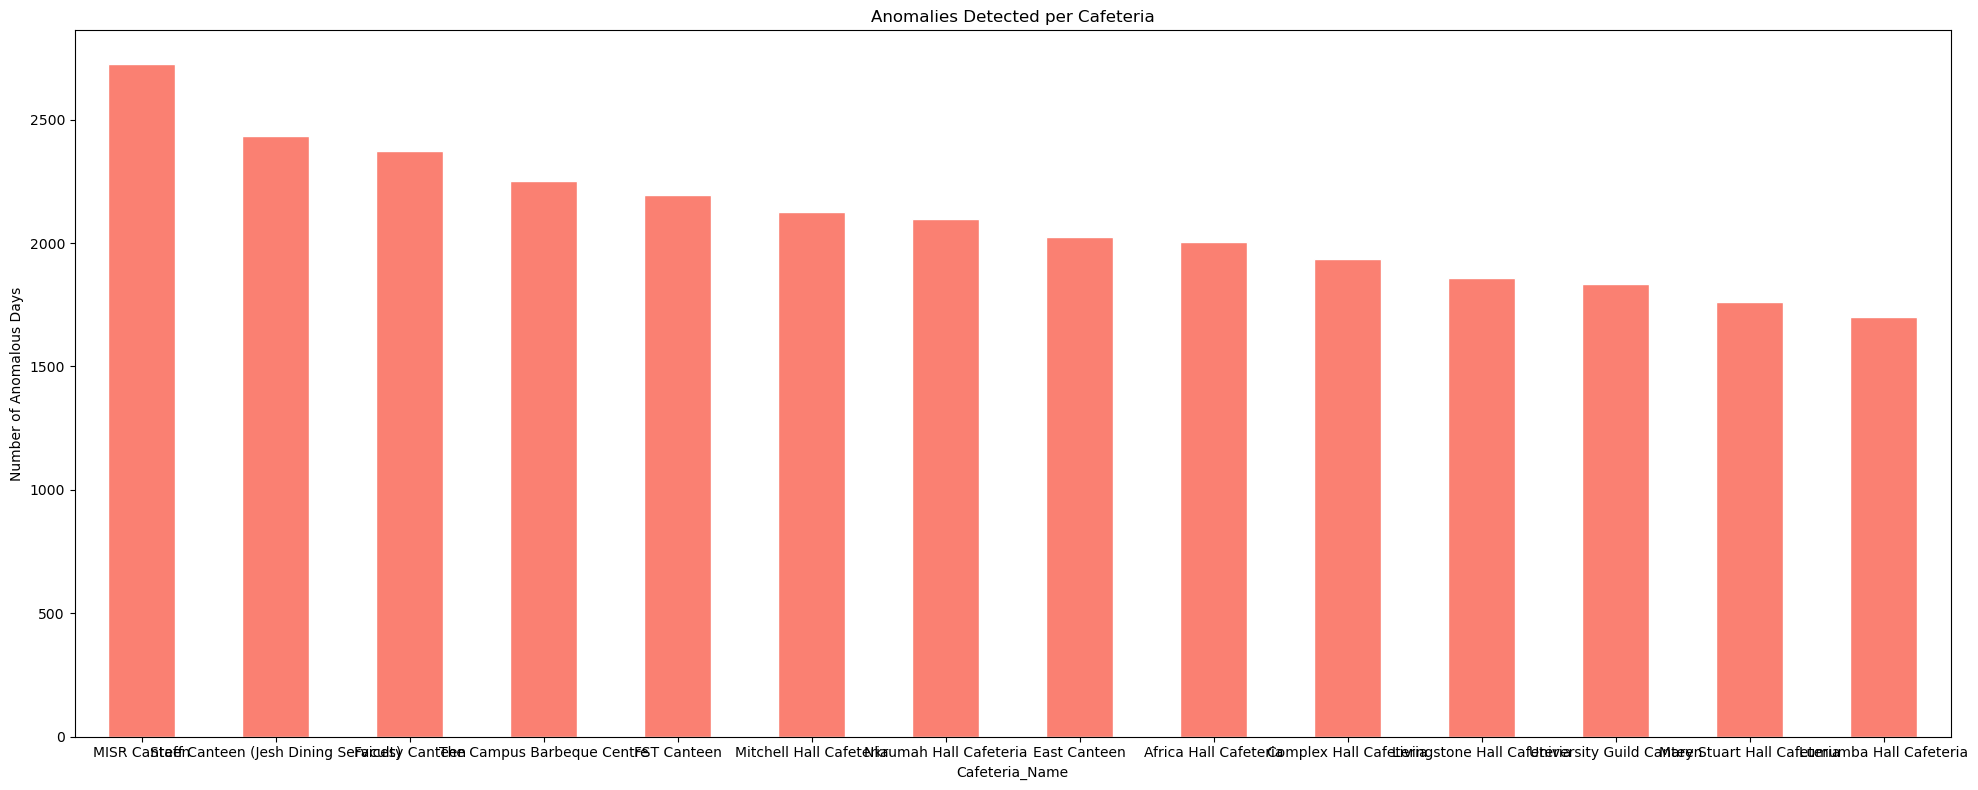

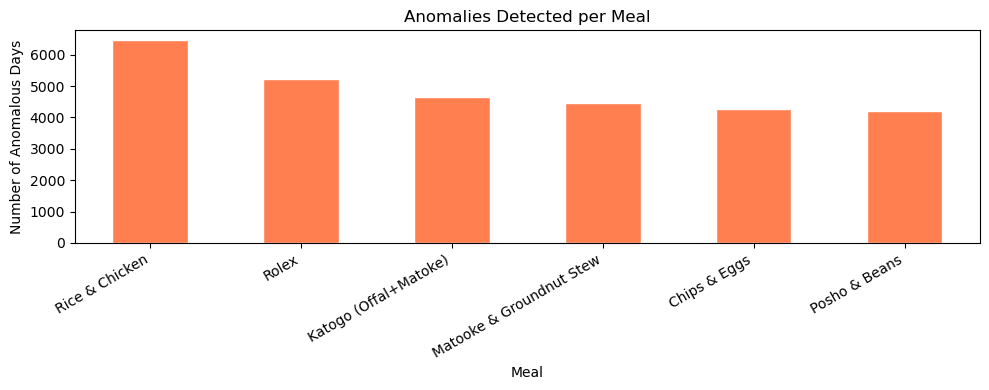

In [22]:
# which cafeterias have the most anomalies?
caf_anomalies = df[df['Anomaly']==True].groupby('Cafeteria_Name').size().sort_values(ascending=False)

plt.figure(figsize=(20, 8))
caf_anomalies.plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Anomalies Detected per Cafeteria')
plt.ylabel('Number of Anomalous Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# which meals are most anomalous?
meal_anomalies = df[df['Anomaly']==True].groupby('Meal').size().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
meal_anomalies.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Anomalies Detected per Meal')
plt.ylabel('Number of Anomalous Days')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [24]:
# print the top 10 most abnormal days
top_anomalies = df[df['Anomaly']==True].nlargest(10, 'Reconstruction_Error')[
    ['Date','Cafeteria_Name','Meal','Portions_Sold','Waste_Portions','Waste_Pct','Reconstruction_Error']
]
print('=== Top 10 Most Abnormal Days ===')
print(top_anomalies.to_string(index=False))

=== Top 10 Most Abnormal Days ===
      Date                       Cafeteria_Name                     Meal  Portions_Sold  Waste_Portions  Waste_Pct  Reconstruction_Error
2025-05-06                Africa Hall Cafeteria                    Rolex            565             240       29.8              3.464945
2024-10-18                Africa Hall Cafeteria                    Rolex            523             216       29.2              2.523122
2025-02-17              Mitchell Hall Cafeteria           Rice & Chicken             52              30       36.6              2.514132
2024-07-15 Staff Canteen (Jesh Dining Services)           Rice & Chicken              7               4       36.4              2.419544
2025-02-13           The Campus Barbeque Centre           Rice & Chicken             35              19       35.2              2.102308
2025-08-07               Nkrumah Hall Cafeteria           Rice & Chicken             40              22       35.5              2.042748
2025-08